# Домашнее задание №7.
**Проект:** Сервис для сегментации опухолей на МРТ головного мозга с системой поиска похожих случаев.

**Источник и состав данных**

Для проекта используется открытый набор данных LGG Segmentation Dataset с платформы Kaggle.

- Источник: изображения получены из базы The Cancer Imaging Archive (TCIA) и относятся к пациентам из The Cancer Genome Atlas (TCGA) с диагностированными глиомами низкой степени злокачественности.
- Состав данных: набор данных включает 2D-срезы магнитно-резонансной томографии (МРТ) головного мозга в формате  .tif.
- Разметка: предоставлены бинарные маски ручной экспертной сегментации, где 1 — пиксель относится к области аномалии, 0 - фон.

In [ ]:
!pip install --upgrade pip --quiet
!pip install pandas numpy matplotlib seaborn torch torchvision tqdm scikit-image opencv-python --quiet

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm
from skimage.io import imread

### 1. Загрузка и очистка данных

Обходим все папки с нашим датасетом, находим все снимки МРТ и маски (разметку опухолей), и сохраняем точные пути к ним. Сортировка гарантирует, что каждый снимок МРТ будет строго соответствовать своей маске.

In [4]:
DATA_PATH = "/Users/nastik/Downloads/archive/kaggle_3m"

images_paths = []
masks_paths = []

for root, dirs, files in os.walk(DATA_PATH):
    for name in files:
        if name.endswith('.tif'):
            if 'mask' in name:
                masks_paths.append(os.path.join(root, name))
            else:
                images_paths.append(os.path.join(root, name))

images_paths.sort()
masks_paths.sort()

print(f"Найдено изображений (МРТ): {len(images_paths)}")
print(f"Найдено масок (разметка): {len(masks_paths)}")

Найдено изображений (МРТ): 3929
Найдено масок (разметка): 3929


В датасете найдено **3929** МРТ-изображений и **3929** масок. Это означает, что разметка полная и количество масок в точности соответствует количеству снимков.

### 2. Анализ данных:
#### 2.1 Анализ размеров снимков и проверка валидности данных
Проанализруем сколько уникальных пациентов в датасете, какого размера представлены изображения, и нет ли среди них "битых" полностью черных снимков.

Анализ размеров изображений: 100%|██████████| 3929/3929 [00:03<00:00, 1012.21it/s]


Всего уникальных пациентов: 110


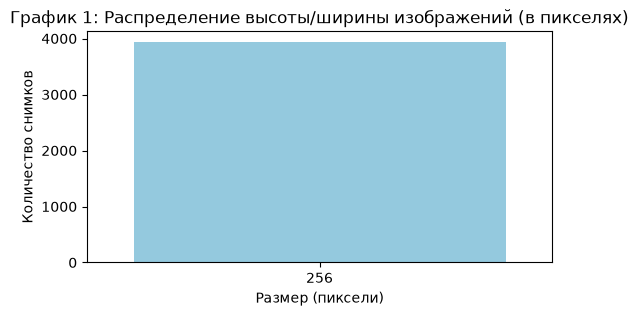

Уникальные размеры изображений в датасете:
   Height  Width  Channels
0     256    256         3


Проверка валидности масок: 100%|██████████| 3929/3929 [00:01<00:00, 2322.69it/s]

Полностью черных изображений (ошибки данных): 0
Полностью черных масок (срезы без опухоли): 2556


In [5]:
patient_ids = set()
image_shapes = []

for path in tqdm(images_paths, desc="Анализ размеров изображений"):
    patient_id = path.split(os.sep)[-2]
    patient_ids.add(patient_id)
    
    img = imread(path)
    image_shapes.append(img.shape)

print(f"Всего уникальных пациентов: {len(patient_ids)}")

df_shapes = pd.DataFrame(image_shapes, columns=['Height', 'Width', 'Channels'])

plt.figure(figsize=(6, 3))
sns.countplot(x='Height', data=df_shapes, color='skyblue')
plt.title("График 1: Распределение высоты/ширины изображений (в пикселях)")
plt.xlabel("Размер (пиксели)")
plt.ylabel("Количество снимков")
plt.show()

print("Уникальные размеры изображений в датасете:")
print(df_shapes.drop_duplicates())

black_images = 0
black_masks = 0

for path in tqdm(images_paths, desc="Проверка валидности изображений"):
    img = imread(path)
    if np.all(img == 0):
        black_images += 1

for path in tqdm(masks_paths, desc="Проверка валидности масок"):
    mask = imread(path, as_gray=True)
    if np.all(mask == 0):
        black_masks += 1

print(f"Полностью черных изображений (ошибки данных): {black_images}")
print(f"Полностью черных масок (срезы без опухоли): {black_masks}")

В наборе данных представлены **110** пациентов, чьи снимки дают в сумме 3929 2D-срезов.
Гистограмма показала, что все изображения уже приведены к единому размеру **256×256** пикселей. Это особенность именно этого Kaggle датасета, так как авторы заранее сделали предобработку и привели снимки к стандартному формату. Нормализация по размеру на данном этапе не требуется.

Битых (полностью черных) МРТ-снимков не найдено (**0** штук).
Найдено **2556** полностью черных масок. Это не ошибка разметки, а означает, что на этих конкретных срезах мозга опухоль отсутствует (фон), что является нормальной клинической картиной.

#### 2.2 Проанализируем, сколько срезов в среднем приходится на **одного** человека и сколько из этих срезов содержат опухоль

Анализ срезов по пациентам: 100%|██████████| 3929/3929 [00:00<00:00, 4802.51it/s]


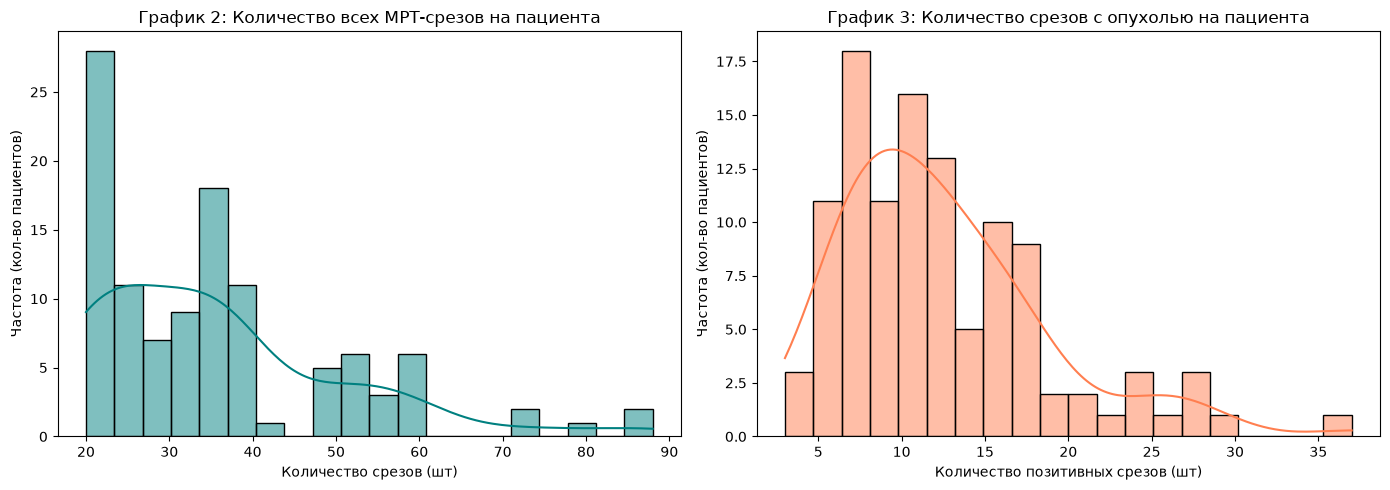

In [6]:
slices_per_patient_dict = {}
positive_slices_per_patient_dict = {}

for img_path, mask_path in tqdm(zip(images_paths, masks_paths), total=len(masks_paths), desc="Анализ срезов по пациентам"):
    patient_id = img_path.split(os.sep)[-2]
    mask = imread(mask_path, as_gray=True)
    has_tumor = 1 if np.sum(mask > 0) > 0 else 0
    
    slices_per_patient_dict[patient_id] = slices_per_patient_dict.get(patient_id, 0) + 1
    
    positive_slices_per_patient_dict[patient_id] = positive_slices_per_patient_dict.get(patient_id, 0) + has_tumor

total_slices = list(slices_per_patient_dict.values())
positive_slices = list(positive_slices_per_patient_dict.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 2: Сколько всего срезов сделали одному пациенту
sns.histplot(total_slices, bins=20, ax=axes[0], color='teal', kde=True)
axes[0].set_title('График 2: Количество всех МРТ-срезов на пациента')
axes[0].set_xlabel('Количество срезов (шт)')
axes[0].set_ylabel('Частота (кол-во пациентов)')

# График 3: Сколько позитивных срезов (с опухолью) у одного пациента
sns.histplot(positive_slices, bins=20, ax=axes[1], color='coral', kde=True)
axes[1].set_title('График 3: Количество срезов с опухолью на пациента')
axes[1].set_xlabel('Количество позитивных срезов (шт)')
axes[1].set_ylabel('Частота (кол-во пациентов)')

plt.tight_layout()
plt.show()

**График 2** показывает, что количество срезов варьируется в зависимости от аппарата МРТ. У большинства пациентов от 20 до 40 срезов.

**График 3** показывает размер самой опухоли. У большинства пациентов опухоль захватывает от 5 до 15 срезов. Однако есть пациенты, у которых опухоль присутствует более чем на 30 срезах (очень крупные опухоли). 

#### 2.3 Проанализируем, насколько часто на срезах присутствует опухоль и какую площадь занимает

Анализ масок на дисбаланс: 100%|██████████| 3929/3929 [00:00<00:00, 4852.11it/s]


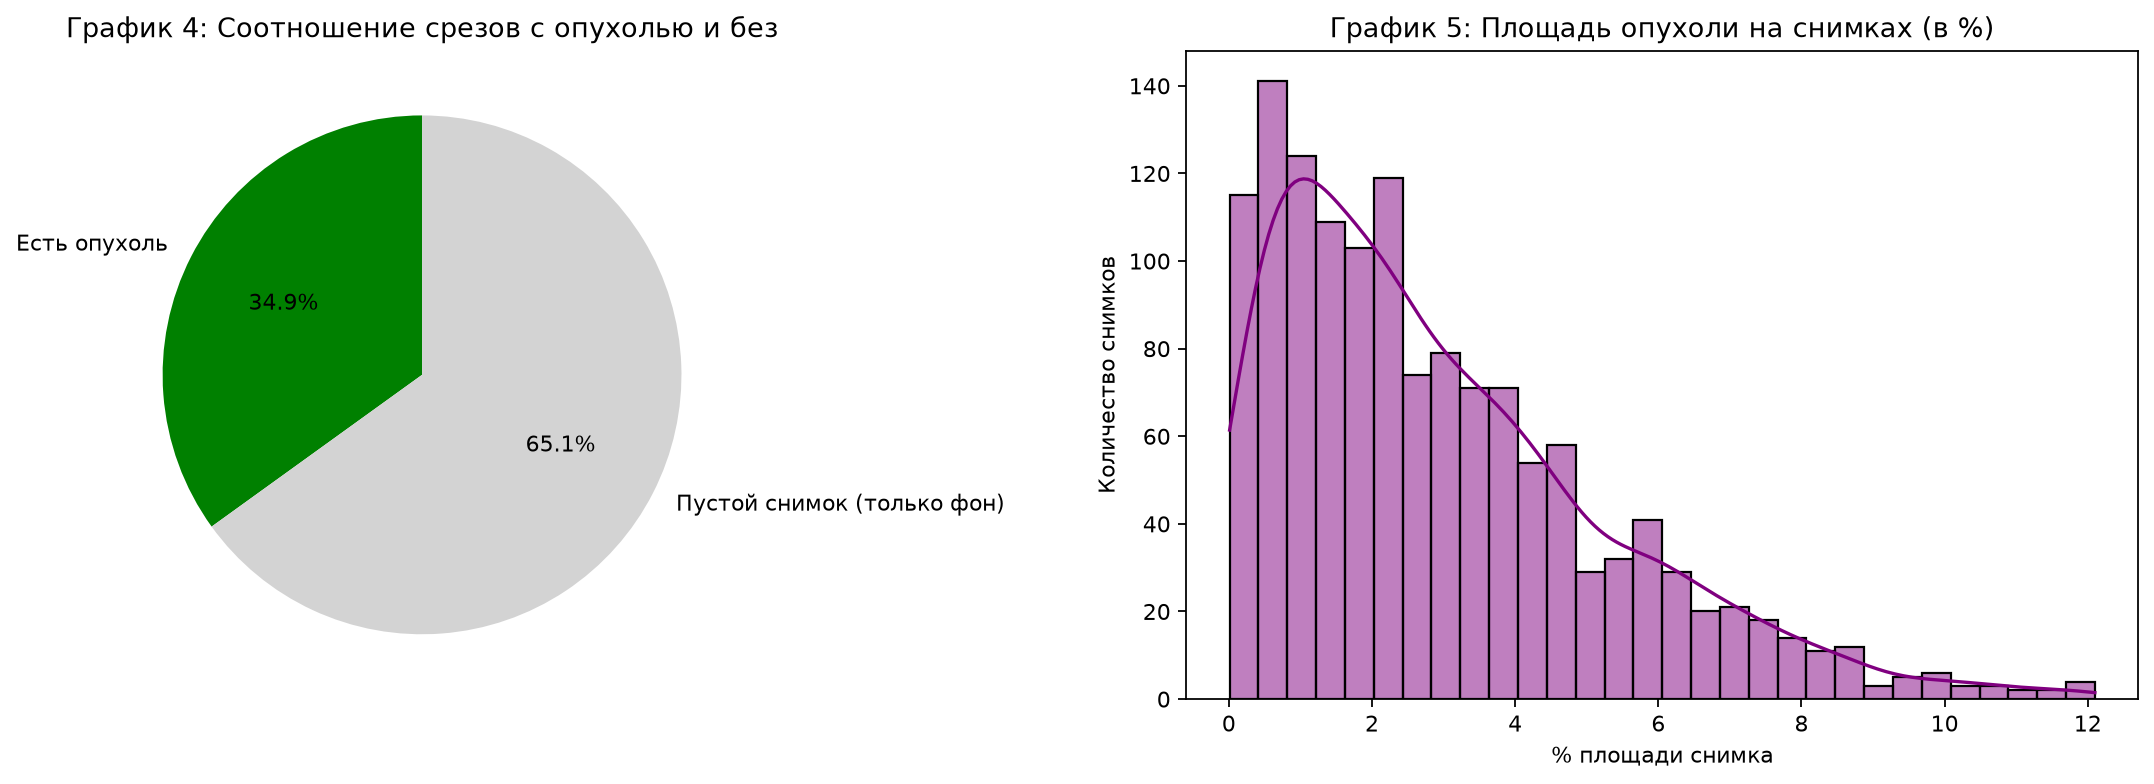

In [7]:
has_tumor_count = 0
empty_mask_count = 0
tumor_area_percentages = []

for path in tqdm(masks_paths, desc="Анализ масок на дисбаланс"):
    mask = imread(path, as_gray=True)
    
    total_pixels = mask.size
    tumor_pixels = np.sum(mask > 0)
    
    if tumor_pixels > 0:
        has_tumor_count += 1
        percentage = (tumor_pixels / total_pixels) * 100
        tumor_area_percentages.append(percentage)
    else:
        empty_mask_count += 1

plt.figure(figsize=(14, 5), dpi=160)

# График 4: Круговая диаграмма баланса классов
plt.subplot(1, 2, 1)
plt.pie([has_tumor_count, empty_mask_count], 
        labels=['Есть опухоль', 'Пустой снимок (только фон)'], 
        autopct='%1.1f%%', colors=['green', 'lightgrey'], startangle=90)
plt.title("График 4: Соотношение срезов с опухолью и без")

# График 5: Гистограмма площади опухоли
plt.subplot(1, 2, 2)
sns.histplot(tumor_area_percentages, bins=30, kde=True, color='purple')
plt.title("График 5: Площадь опухоли на снимках (в %)")
plt.xlabel("% площади снимка")
plt.ylabel("Количество снимков")

plt.tight_layout()
plt.show()


**График 4** показывает дисбаланс данных: около 65% всех МРТ-срезов в датасете не содержат опухоли (являются чистым фоном). 

**График 5** демонстрирует дисбаланс уже внутри самих позитивных снимков. Даже если опухоль присутствует на кадре, она чаще всего занимает крошечную область — от 0.5% до 3% площади снимка.

**Вывод:** Из-за такого сильного дисбаланса стандартная метрика Accuracy (доля правильных ответов) нам не подходит, так как предсказание всегда черного экрана даст ложную точность в 65%+. Необходимо использовать метрику **Dice Coefficient**, а для обучения нейросети применять основанную на ней функцию **Dice Loss**. Также График 5 доказывает необходимость обрезки пустого черного фона вокруг мозга перед подачей в нейросеть.

#### 2.4 Проанализируем распределение яркости МРТ-снимков (на примере 3-х)

На примере нескольких случайных МРТ-снимков посмотрим, насколько сильно отличается их контрастность и яркость (интенсивность пикселей). Это поможет понять, нужна ли нам стандартизация яркости перед обучением нейросети.

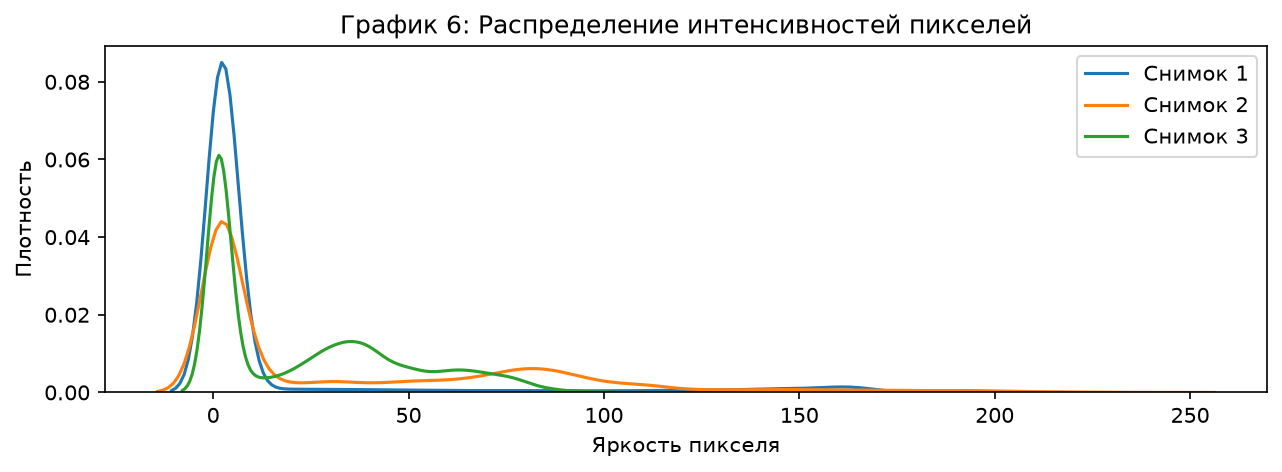

In [8]:
plt.figure(figsize=(10, 3), dpi=150)

sample_images = random.sample(images_paths, 3)

for i, path in enumerate(sample_images):
    img = imread(path)
    pixels = img[:,:,0].flatten()
    pixels_no_background = pixels[pixels > 0]
    
    sns.kdeplot(pixels_no_background, label=f"Снимок {i+1}")

plt.title("График 6: Распределение интенсивностей пикселей")
plt.xlabel("Яркость пикселя")
plt.ylabel("Плотность")
plt.legend()
plt.show()


График 6 наглядно показывает, что кривые плотности яркости пикселей для разных МРТ-снимков не совпадают (имеют разные пики и размах). Это могло произойти из-за того, что данные собирались с различных томографов с разными настройками.

**Вывод:** Подавать сырые снимки в нейросеть нельзя, она не сможет выучить единые признаки опухоли из-за скачков яркости. Потребуется сделать нормализацию интенсивностей.

#### 2.5 Визуализация конкретного примера (МРТ + Маска)

Убедимся в корректности разметки. Посмотрим на случайный снимок мозга и соответствующую ему маску опухоли.

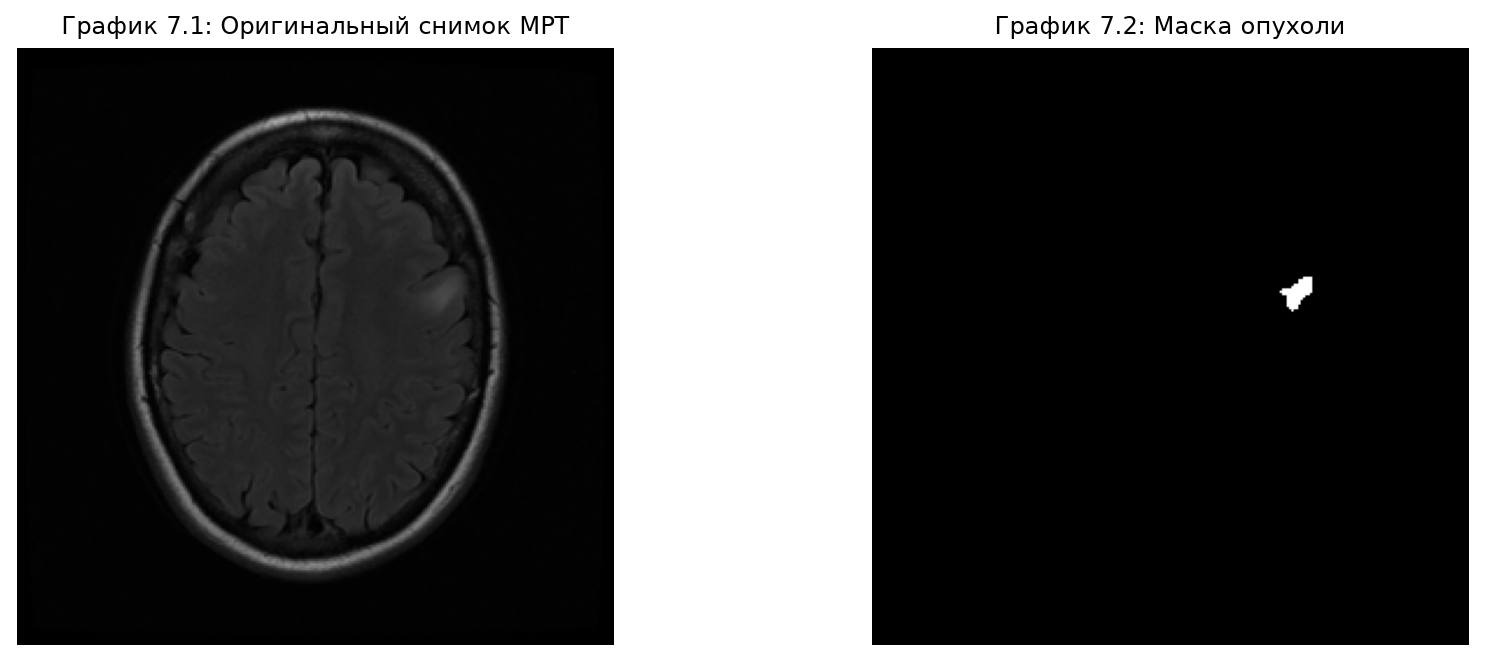

In [9]:
random.seed(42)

positive_samples = []
for p in masks_paths:
    if np.sum(imread(p, as_gray=True) > 0) > 0:
        positive_samples.append(p)

sample_mask_path = random.choice(positive_samples)
sample_img_path = sample_mask_path.replace('_mask', '')

img = imread(sample_img_path)
mask = imread(sample_mask_path, as_gray=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=170)
axes[0].imshow(img)
axes[0].set_title('График 7.1: Оригинальный снимок МРТ', fontsize=10)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('График 7.2: Маска опухоли', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

По визуальному осмотру видно, что маска выделяет область повышенной интенсивности на снимке МРТ, соответствующую опухоли. Это подтверждает качество разметки.

#### Оценка качества разметки

По визуальному осмотру пары «МРТ‑срез + маска» маска корректно выделяет область аномалии на снимке. Полностью черные маски соответствуют срезам без опухоли, что является ожидаемой клинической ситуацией, а не ошибкой разметки. Разметка в датасете выполнена вручную на данных TCIA/TCGA и использовалась в научных работах по сегментации глиом низкой степени злокачественности.

На данном этапе дополнительное улучшение разметки не требуется.

#### Описание алгоритма формирования выборки и стратегии валидации

Для задачи медицинской сегментации важно исключить утечку данных между обучающей и валидационной выборками и учесть особенности данных.

- Алгоритм формирования выборки: исходный датасет сгруппирован по директориям, где каждая папка соответствует отдельному пациенту. Все 2D‑срезы и маски внутри папки принадлежат одному человеку. При подготовке данных следует формировать выборки именно на уровне пациентов, а не отдельных срезов.

- Стратегия валидации: используется разбиение по пациентам, а не по отдельным срезам. Каждый пациент целиком попадает либо в обучающую (train), либо в валидационную (validation) выборку. Это позволяет избежать ситуации, когда срезы одного и того же мозга оказываются одновременно в train и validation и искусственно завышают оценку качества модели.

- Учет размера опухоли: на этапе EDA было проанализировано, какую долю снимка в процентах обычно занимает опухоль. Выяснилось, что чаще всего маска очень маленькая, а большие опухоли встречаются редко. Каждый пациент дает несколько срезов: часть без опухоли, часть с небольшой маской, часть с более крупной. При разбиении по пациентам эти разные случаи попадают и в обучающую, и в валидационную выборки, поэтому модель обучается и проверяется сразу на примерах с разным размером опухоли.

- Учет различий в интенсивностях: EDA показал, что распределения яркости пикселей для разных МРТ‑снимков отличаются. Для сглаживания этих различий на этапе предобработки планируется нормализовать интенсивности, чтобы распределения интенсивностей в train и validation были сопоставимыми и разбиение по пациентам оставалось корректным.

- Отбор валидации: из общего количества 110 пациентов случайным образом (с фиксированным random seed для воспроизводимости) отбирается, например, 10 пациентов для валидационной выборки, а остальные используются для обучения. При необходимости схему можно расширить до k‑fold cross‑validation по пациентам, чтобы дополнительно оценить устойчивость результатов.

### 3. Выбор и обучение моделей

#### Инициализация и настройки окружения
Фиксируем random seed для воспроизводимости экспериментов и настраиваем функции очистки памяти, так как работа с медицинскими изображениями требует строгой оптимизации ресурсов GPU.

In [1]:
!pip install segmentation-models-pytorch --quiet
!pip install qdrant-client --quiet

import gc
import random
import torch
import os
import torch.nn as nn
from collections import OrderedDict
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pickle
import kagglehub
from pathlib import Path
from skimage.io import imread
from skimage.transform import resize
from tqdm import tqdm
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
import torchvision.transforms as T
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct, Filter, FieldCondition, Range, MatchValue
import torch.nn.functional as F

def free_memory(*objects_to_delete):
    for obj in objects_to_delete:
        if obj in locals() or obj in globals():
            del obj

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    print("Память очищена")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Все сиды зафиксированы на числе {seed}.")

seed_everything(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 22.4 MB/s eta 0:00:00
Все сиды зафиксированы на числе 42.


#### Предобработка и Feature Engineering

Медицинские снимки из разных томографов имеют различный контраст, яркость и содержат много пустого фона. 
Для оптимизации обучения реализован пайплайн подготовки данных с кэшированием (сохранением в `.pkl`).

**Ключевые шаги предобработки:**
1. **Cropping:** обрезка черного фона вокруг мозга по всем осям. Нейросеть не будет тратить вычислительные ресурсы на анализ "пустоты".
2. **Padding & Resizing:** приведение всех снимков к единому квадратному размеру (160x160) с сохранением пропорций анатомии.
3. **Нормализация:** устранение скачков яркости томографов путем отсечения экстремальных перцентилей (10 и 99) и Min-Max шкалирования.
4. **Строгая валидация:** данные разделены строго по ID пациентов. Это важно в медицине, чтобы соседние срезы мозга одного и того же человека не попали одновременно в `train` и `valid` (предотвращение утечки данных).

In [ ]:
# !rm -rf /kaggle/working/dataset_cache.pkl

In [2]:
try:
    download_path_str = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
except Exception as e:
    print(f"Не удалось скачать датасет: {e}")
    raise

download_dir = Path(download_path_str)
DATA_PATH = download_dir / "kaggle_3m"
print(f"Датасет найден по пути: {DATA_PATH}")

working_dir = Path.cwd()
CACHE_FILE = working_dir / "dataset_cache.pkl"
IMAGE_SIZE = 160

def crop_sample(x):
    volume, mask = x
    volume[volume < np.max(volume) * 0.1] = 0
    z_projection = np.max(np.max(np.max(volume, axis=-1), axis=-1), axis=-1)
    z_nonzero = np.nonzero(z_projection)
    z_min, z_max = np.min(z_nonzero), np.max(z_nonzero) + 1
    y_projection = np.max(np.max(np.max(volume, axis=0), axis=-1), axis=-1)
    y_nonzero = np.nonzero(y_projection)
    y_min, y_max = np.min(y_nonzero), np.max(y_nonzero) + 1
    x_projection = np.max(np.max(np.max(volume, axis=0), axis=0), axis=-1)
    x_nonzero = np.nonzero(x_projection)
    x_min, x_max = np.min(x_nonzero), np.max(x_nonzero) + 1
    return volume[z_min:z_max, y_min:y_max, x_min:x_max], mask[z_min:z_max, y_min:y_max, x_min:x_max]

def pad_sample(x):
    volume, mask = x
    a, b = volume.shape[1], volume.shape[2]
    if a == b:
        return volume, mask
    diff = (max(a, b) - min(a, b)) / 2.0
    if a > b:
        padding = ((0, 0), (0, 0), (int(np.floor(diff)), int(np.ceil(diff))))
    else:
        padding = ((0, 0), (int(np.floor(diff)), int(np.ceil(diff))), (0, 0))
    mask = np.pad(mask, padding, mode="constant", constant_values=0)
    padding = padding + ((0, 0),)
    volume = np.pad(volume, padding, mode="constant", constant_values=0)
    return volume, mask

def resize_sample(x, size=256):
    volume, mask = x
    v_shape = volume.shape
    out_shape = (v_shape[0], size, size)
    mask = resize(mask, output_shape=out_shape, order=0, mode="constant", cval=0, anti_aliasing=False)
    out_shape = out_shape + (v_shape[3],)
    volume = resize(volume, output_shape=out_shape, order=2, mode="constant", cval=0, anti_aliasing=False)
    return volume, mask

def normalize_volume(volume):
    p10 = np.percentile(volume, 10)
    p99 = np.percentile(volume, 99)
    volume = volume.astype(np.float32)
    volume = np.clip(volume, p10, p99)
    volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume) + 1e-5)
    return volume

def prepare_dataset_and_cache(images_dir_path, subset="train", seed=42):
    volumes = {}
    masks = {}
    print(f"[{subset}] Чтение снимков...")

    all_tifs = list(images_dir_path.rglob("*.tif"))
    patient_dirs = sorted(list(set([f.parent for f in all_tifs])))

    for p_dir in patient_dirs:
        patient_files = sorted(list(p_dir.glob("*.tif")), key=lambda x: int(x.name.split(".")[-2].split("_")[4]))

        image_slices = []
        mask_slices = []

        for filepath in patient_files:
            if "mask" in filepath.name:
                mask_img = imread(str(filepath), as_gray=True)
                mask_img = (mask_img > 0).astype(np.float32)
                mask_slices.append(mask_img)
            else:
                image_slices.append(imread(str(filepath)))

        if len(image_slices) > 0:
            patient_id = p_dir.name
            volumes[patient_id] = np.array(image_slices[1:-1])
            masks[patient_id] = np.array(mask_slices[1:-1])

    patients = sorted(list(volumes.keys()))

    if subset != "all":
        random.seed(seed)
        validation_patients = random.sample(patients, k=10)
        if subset == "validation":
            patients = validation_patients
        else:
            patients = sorted(list(set(patients).difference(validation_patients)))

    print(f"[{subset}] Предобработка...")
    raw_volumes = [(volumes[k], masks[k]) for k in patients]

    raw_volumes = [crop_sample(v) for v in tqdm(raw_volumes, desc=f"[{subset}] Cropping")]
    raw_volumes = [pad_sample(v) for v in tqdm(raw_volumes, desc=f"[{subset}] Padding")]
    raw_volumes = [resize_sample(v, size=IMAGE_SIZE) for v in tqdm(raw_volumes, desc=f"[{subset}] Resizing")]
    raw_volumes = [(normalize_volume(v), m) for v, m in tqdm(raw_volumes, desc=f"[{subset}] Normalizing")]

    slice_weights = [m.sum(axis=-1).sum(axis=-1) for v, m in raw_volumes]
    slice_weights = [(s + (s.sum() * 0.1 / len(s))) / (s.sum() * 1.1) for s in slice_weights]
    raw_volumes = [(v, m[..., np.newaxis]) for (v, m) in raw_volumes]

    num_slices = [v.shape[0] for v, m in raw_volumes]
    patient_slice_index = list(zip(
        sum([[i] * num_slices[i] for i in range(len(num_slices))], []),
        sum([list(range(x)) for x in num_slices], [])
    ))

    return {
        "volumes": raw_volumes,
        "slice_weights": slice_weights,
        "patient_slice_index": patient_slice_index,
        "patients": patients
    }

if CACHE_FILE.exists():
    try:
        print(f"Найден кэш ({CACHE_FILE}). Загружается готовый датасет...")
        with open(CACHE_FILE, "rb") as f:
            cache_data = pickle.load(f)

        train_data = cache_data["train"]
        valid_data = cache_data["valid"]
        print("Кэш успешно загружен")

    except Exception as e:
        print(f"Ошибка чтения кэша: {e}")
        print("Кэш удаляется, датасет будет собран заново...")

        CACHE_FILE.unlink(missing_ok=True)

        train_data = prepare_dataset_and_cache(DATA_PATH, subset="train")
        valid_data = prepare_dataset_and_cache(DATA_PATH, subset="validation")

        print("Сохраняются обработанные данные в новый кэш...")
        with open(CACHE_FILE, "wb") as f:
            pickle.dump({"train": train_data, "valid": valid_data}, f)

        print("Новый кэш успешно создан")
else:
    print("Кэш не найден. Начинается обработка...")

    train_data = prepare_dataset_and_cache(DATA_PATH, subset="train")
    valid_data = prepare_dataset_and_cache(DATA_PATH, subset="validation")

    print("Сохраняются обработанные данные в кэш...")
    with open(CACHE_FILE, "wb") as f:
        pickle.dump({"train": train_data, "valid": valid_data}, f)

    print("Готово")

Датасет найден по пути: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Найден кэш (/kaggle/working/dataset_cache.pkl). Загружается готовый датасет...
Кэш успешно загружен


#### Генерация данных и аугментации

Из-за сильного дисбаланса классов (большинство 2D-срезов мозга пациента не содержат опухоль) реализован кастомный класс `FastBrainDataset`. 
В нем используется **взвешенное сэмплирование**: при случайном выборе срезов DataLoader чаще выдает те кадры, на которых присутствует маска опухоли.

Для повышения робастности модели и предотвращения переобучения применяются аугментации через библиотеку **Albumentations**: случайные небольшие сдвиги, повороты и изменения яркости и контраста.

In [3]:
class FastBrainDataset(Dataset):
    in_channels = 3
    out_channels = 1
    def __init__(self, data_dict, transform=None, random_sampling=True):
        self.volumes = data_dict["volumes"]
        self.slice_weights = data_dict["slice_weights"]
        self.patient_slice_index = data_dict["patient_slice_index"]
        self.patients = data_dict["patients"]
        self.transform = transform
        self.random_sampling = random_sampling

    def __len__(self): return len(self.patient_slice_index)

    def __getitem__(self, idx):
        patient = self.patient_slice_index[idx][0]
        slice_n = self.patient_slice_index[idx][1]

        if self.random_sampling:
            patient = np.random.randint(len(self.volumes))
            slice_n = np.random.choice(range(self.volumes[patient][0].shape[0]), p=self.slice_weights[patient])

        v, m = self.volumes[patient]
        image, mask = v[slice_n], m[slice_n]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.transpose(2, 0, 1)
        mask = mask.transpose(2, 0, 1)

        mask = (mask > 0).astype(np.float32)
        
        return torch.from_numpy(image.astype(np.float32)), torch.from_numpy(mask)

batch_size = 32
epochs = 50
lr = 0.0002
workers = 2
weights_path = "./"
patience = 15

def get_loaders(train_dict, valid_dict, batch_size=32):
    def worker_init(worker_id):
        np.random.seed(42 + worker_id)

    train_transform = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2)
    ])

    train_dataset = FastBrainDataset(train_dict, transform=train_transform)
    valid_dataset = FastBrainDataset(valid_dict, transform=None, random_sampling=False)

    loader_train = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        drop_last=True, num_workers=2, worker_init_fn=worker_init, pin_memory=True
    )
    loader_valid = DataLoader(
        valid_dataset, batch_size=batch_size, drop_last=False,
        num_workers=2, worker_init_fn=worker_init, pin_memory=True
    )
    return loader_train, loader_valid


#### Базовая архитектура, функция потерь и метрики

Для оценки качества сегментации используется коэффициент Дайса (**Dice Coefficient**).

В качестве базовой модели выступает классический **UNet**, написанный с нуля. Функция потерь — **Dice Loss**, идеально подходящая для задач с сильным дисбалансом пикселей, когда опухоль занимает крошечную часть кадра.

In [4]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, init_features=32):
        super(UNet, self).__init__()
        features = init_features
        self.encoder1 = UNet._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = UNet._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = UNet._block(features * 8, features * 16, name="bottleneck")
        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = UNet._block(features * 2, features, name="dec1")
        self.conv = nn.Conv2d(in_channels=features, out_channels=out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        return torch.sigmoid(self.conv(dec1))

    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(OrderedDict([
            (name + "conv1", nn.Conv2d(in_channels=in_channels, out_channels=features, kernel_size=3, padding=1, bias=False)),
            (name + "norm1", nn.BatchNorm2d(num_features=features)),
            (name + "relu1", nn.ReLU(inplace=True)),
            (name + "conv2", nn.Conv2d(in_channels=features, out_channels=features, kernel_size=3, padding=1, bias=False)),
            (name + "norm2", nn.BatchNorm2d(num_features=features)),
            (name + "relu2", nn.ReLU(inplace=True)),
        ]))

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        self.smooth = 1.0

    def forward(self, y_pred, y_true):
        assert y_pred.size() == y_true.size()
        y_pred = y_pred[:, 0].contiguous().view(-1)
        y_true = y_true[:, 0].contiguous().view(-1)
        intersection = (y_pred * y_true).sum()
        dsc = (2. * intersection + self.smooth) / (
            y_pred.sum() + y_true.sum() + self.smooth
        )
        return 1. - dsc 

def dsc_metric(y_pred, y_true, threshold=0.5):
    y_pred = (y_pred > threshold).astype(int)
    y_true = np.round(y_true).astype(int)

    if np.sum(y_true) == 0 and np.sum(y_pred) == 0:
        return 1.0
        
    intersection = np.sum(y_pred * y_true)
    return (2. * intersection) / (np.sum(y_pred) + np.sum(y_true) + 1e-5)

def dsc_per_volume(validation_pred, validation_true, patient_slice_index, threshold=0.5):
    dsc_list = []
    num_slices = np.bincount([p[0] for p in patient_slice_index])
    index = 0
    
    for p in range(len(num_slices)):
        y_pred = np.array(validation_pred[index:index + num_slices[p]])
        y_true = np.array(validation_true[index:index + num_slices[p]])
        dsc_list.append(dsc_metric(y_pred, y_true, threshold=threshold))
        index += num_slices[p]
        
    return dsc_list

#### Обучение базовой модели

Запускаем обучение Baseline модели. В процессе отслеживаем функцию потерь на обучающей выборке и метрику Dice Coefficient на отложенной валидационной выборке. Применяется Early stopping при отсутствии улучшений 15 эпох подряд.

In [9]:
def train_base_unet_experiment():
    free_memory()
    seed_everything()

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Обучение базового UNet на устройстве: {device}")

    loader_train, loader_valid = get_loaders(train_data, valid_data, batch_size=batch_size)

    unet = UNet()
    unet.to(device)

    dsc_loss = DiceLoss()
    optimizer = optim.Adam(unet.parameters(), lr=lr)
    scaler = torch.amp.GradScaler()

    best_validation_loss = float("inf")
    best_model_dice = 0.0
    patience_counter = 0

    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Train]"):
            x, y_true = x.to(device, non_blocking=True), y_true.to(device, non_blocking=True)
            optimizer.zero_grad()

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())

        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x, y_true = x.to(device, non_blocking=True), y_true.to(device, non_blocking=True)
                
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())

                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())

        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))

        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)

        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unet_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break

    print(f"\nОбучение завершено. Лучший Dice: {best_model_dice:.4f}")

    return history

history_unet = train_base_unet_experiment()

Память очищена
Все сиды зафиксированы на числе 42.
Обучение базового UNet на устройстве: cuda:0


Эпоха 1/50 [Train]: 100%|██████████| 104/104 [00:14<00:00,  7.03it/s]


Epoch 1 | Train Loss: 0.8353 | Val Loss: 0.9279 | Val Dice: 0.2002
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.52it/s]


Epoch 2 | Train Loss: 0.7940 | Val Loss: 0.9112 | Val Dice: 0.3498
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 43 | Train Loss: 0.0472 | Val Loss: 0.1547 | Val Dice: 0.8316
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 44/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.78it/s]


Epoch 44 | Train Loss: 0.0465 | Val Loss: 0.1548 | Val Dice: 0.8276
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 45/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.77it/s]


Epoch 45 | Train Loss: 0.0462 | Val Loss: 0.1417 | Val Dice: 0.8396
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Обучение завершено. Лучший Dice: 0.8476


#### Усложненная модель: UnetPlusPlus + EfficientNet-b3

В качестве усложненной модели используется архитектура **UnetPlusPlus** с предобученным энкодером EfficientNet-b3:

- Этап 1: Энкодер заморожен, обучается только декодер. Это снижает риск переобучения и ускоряет сходимость.
- Этап 2: Энкодер размораживается, вся сеть дообучается с низким lr.

In [7]:
def train_efficientnet_experiment():
    free_memory()
    seed_everything()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Обучение UnetPlusPlus на устройстве: {device}")

    train_dataset = FastBrainDataset(train_data, transform=None)
    valid_dataset = FastBrainDataset(valid_data, transform=None, random_sampling=False)

    loader_train = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    loader_valid = DataLoader(valid_dataset, batch_size=32, drop_last=False, num_workers=2, pin_memory=True)

    unet = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3",
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    for param in unet.encoder.parameters():
        param.requires_grad = False
    print("Энкодер заморожен. Обучается только декодер.")

    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=lr)
    scaler = torch.amp.GradScaler()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )

    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Train]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)

            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)

                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)

        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unetplusplus_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break
                
    print(f"\nОбучение завершено. Лучший Dice: {best_model_dice:.4f}")
    
    return history
    
history_effnet_stage1 = train_efficientnet_experiment()


Память очищена
Все сиды зафиксированы на числе 42.
Обучение UnetPlusPlus на устройстве: cuda:0


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Энкодер заморожен. Обучается только декодер.


Эпоха 1/50 [Train]: 100%|██████████| 104/104 [00:20<00:00,  5.06it/s]


...

Epoch 26 | Train Loss: 0.0387 | Val Loss: 0.1496 | Val Dice: 0.8415
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 27/50 [Train]: 100%|██████████| 104/104 [00:16<00:00,  6.17it/s]


Epoch 27 | Train Loss: 0.0381 | Val Loss: 0.1477 | Val Dice: 0.8438
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 28/50 [Train]: 100%|██████████| 104/104 [00:16<00:00,  6.17it/s]


Epoch 28 | Train Loss: 0.0373 | Val Loss: 0.1473 | Val Dice: 0.8439
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Обучение завершено. Лучший Dice: 0.8506


In [8]:
def finetune_efficientnet_experiment():
    free_memory()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Этап 2: Разморозка UnetPlusPlus на {device}")

    loader_train, loader_valid = get_loaders(train_data, valid_data, batch_size=32)

    unet = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3", 
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    state_dict = torch.load(os.path.join(weights_path, "unetplusplus_best.pt"))
    unet.load_state_dict(state_dict)

    for param in unet.parameters():
        param.requires_grad = True
    print("Энкодер разморожен. Обучается вся сеть целиком.")
    
    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)

    finetune_lr = 0.00002
    optimizer = optim.Adam(unet.parameters(), lr=finetune_lr)
    scaler = torch.amp.GradScaler()
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )
    
    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Разморозка]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)
            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)
                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)
        
        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unetplusplus_finetuned_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break

    print(f"\nРазморозка завершена. Лучший Dice: {best_model_dice:.4f}")

    return history
    
history_effnet_stage2 = finetune_efficientnet_experiment()


Память очищена
Этап 2: Разморозка UnetPlusPlus на cuda:0
Энкодер разморожен. Обучается вся сеть целиком.


Эпоха 1/50 [Разморозка]: 100%|██████████| 104/104 [00:31<00:00,  3.35it/s]


Epoch 1 | Train Loss: 0.0942 | Val Loss: 0.1370 | Val Dice: 0.8599
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Разморозка]: 100%|██████████| 104/104 [00:26<00:00,  3.95it/s]


Epoch 2 | Train Loss: 0.0808 | Val Loss: 0.1324 | Val Dice: 0.8637
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 15 | Train Loss: 0.0565 | Val Loss: 0.1291 | Val Dice: 0.8616
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 16/50 [Разморозка]: 100%|██████████| 104/104 [00:25<00:00,  4.10it/s]


Epoch 16 | Train Loss: 0.0564 | Val Loss: 0.1290 | Val Dice: 0.8617
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 17/50 [Разморозка]: 100%|██████████| 104/104 [00:25<00:00,  4.10it/s]


Epoch 17 | Train Loss: 0.0563 | Val Loss: 0.1292 | Val Dice: 0.8614
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Разморозка завершена. Лучший Dice: 0.8637


#### Улучшенная архитектура модели

В рамках предыдущих этапов проекта был обучен базовый UNet с нуля, а также UnetPlusPlus с предобученным сверточным энкодером (EfficientNet-b3). Это позволило достичь метрики Dice на уровне ~0.86. 

Был проведен эксперимент и заменен CNN-энкодер на современный легковесный трансформер — **SegFormer (mit_b2)**, предобученный на ImageNet. 

Итоговая улучшенная модель представляет собой **гибридный трансформер (SegFormer mit_b2 Encoder + UNet Decoder)**.

In [10]:
def train_transformer_experiment():
    free_memory()
    seed_everything()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Обучение на устройстве: {device}")

    train_dataset = FastBrainDataset(train_data, transform=None)
    valid_dataset = FastBrainDataset(valid_data, transform=None, random_sampling=False)

    loader_train = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    loader_valid = DataLoader(valid_dataset, batch_size=32, drop_last=False, num_workers=2, pin_memory=True)

    unet = smp.Unet(
        encoder_name="mit_b2",
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    for param in unet.encoder.parameters():
        param.requires_grad = False
    print("Энкодер заморожен. Обучается только декодер.")

    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=lr)
    scaler = torch.amp.GradScaler()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )

    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Train]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)

            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)

                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)

        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unet_transformer_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break
                
    print(f"\nОбучение завершено. Лучший Dice: {best_model_dice:.4f}")
    
    return history
    
history_transf_stage1 = train_transformer_experiment()


Память очищена
Все сиды зафиксированы на числе 42.
Обучение на устройстве: cuda:0


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

Энкодер заморожен. Обучается только декодер.


Эпоха 1/50 [Train]: 100%|██████████| 104/104 [00:11<00:00,  9.12it/s]


...

Epoch 32 | Train Loss: 0.0424 | Val Loss: 0.1623 | Val Dice: 0.8058
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 33/50 [Train]: 100%|██████████| 104/104 [00:09<00:00, 11.36it/s]


Epoch 33 | Train Loss: 0.0432 | Val Loss: 0.1613 | Val Dice: 0.8070
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 34/50 [Train]: 100%|██████████| 104/104 [00:09<00:00, 11.36it/s]


Epoch 34 | Train Loss: 0.0425 | Val Loss: 0.1616 | Val Dice: 0.8065
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Обучение завершено. Лучший Dice: 0.8206


In [12]:
def finetune_transformer_experiment():
    free_memory()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Этап 2: Разморозка Unet на {device}")

    loader_train, loader_valid = get_loaders(train_data, valid_data, batch_size=32)

    unet = smp.Unet(
        encoder_name="mit_b2",
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    state_dict = torch.load(os.path.join(weights_path, "unet_transformer_best.pt"))
    unet.load_state_dict(state_dict)

    for param in unet.parameters():
        param.requires_grad = True
    print("Энкодер разморожен. Обучается вся сеть целиком.")
    
    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)

    finetune_lr = 0.00002
    optimizer = optim.Adam(unet.parameters(), lr=finetune_lr)
    scaler = torch.amp.GradScaler()
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )
    
    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Разморозка]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)
            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)
                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)
        
        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unet_transformer_finetuned_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break

    print(f"\nРазморозка завершена. Лучший Dice: {best_model_dice:.4f}")

    return history
    
history_transf_stage2 = finetune_transformer_experiment()


Память очищена
Этап 2: Разморозка Unet на cuda:0
Энкодер разморожен. Обучается вся сеть целиком.


Эпоха 1/50 [Разморозка]: 100%|██████████| 104/104 [00:16<00:00,  6.27it/s]


Epoch 1 | Train Loss: 0.0945 | Val Loss: 0.1328 | Val Dice: 0.8686
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Разморозка]: 100%|██████████| 104/104 [00:16<00:00,  6.14it/s]


Epoch 2 | Train Loss: 0.0820 | Val Loss: 0.1233 | Val Dice: 0.8775
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 20 | Train Loss: 0.0517 | Val Loss: 0.1142 | Val Dice: 0.8810
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 21/50 [Разморозка]: 100%|██████████| 104/104 [00:16<00:00,  6.27it/s]


Epoch 21 | Train Loss: 0.0512 | Val Loss: 0.1144 | Val Dice: 0.8807
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 22/50 [Разморозка]: 100%|██████████| 104/104 [00:16<00:00,  6.24it/s]


Epoch 22 | Train Loss: 0.0513 | Val Loss: 0.1140 | Val Dice: 0.8811
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Разморозка завершена. Лучший Dice: 0.8842


**Результат эксперимента:** 

Как видно из логов обучения, гибридная трансформерная архитектура позволила улучшить качество, увеличив метрику **Dice до ~0.88+**.

### 4. Оценка метрик качества и анализ результатов

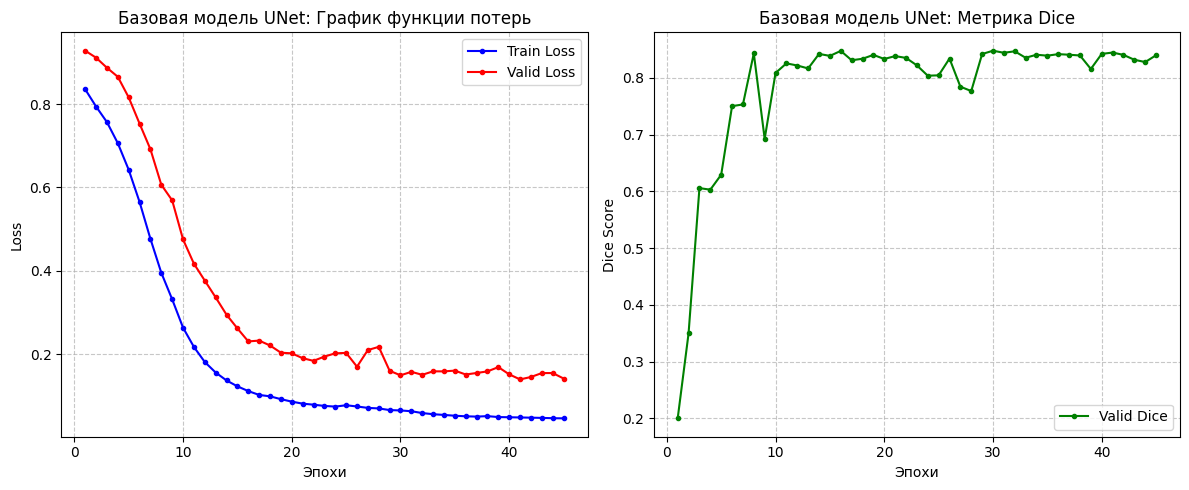

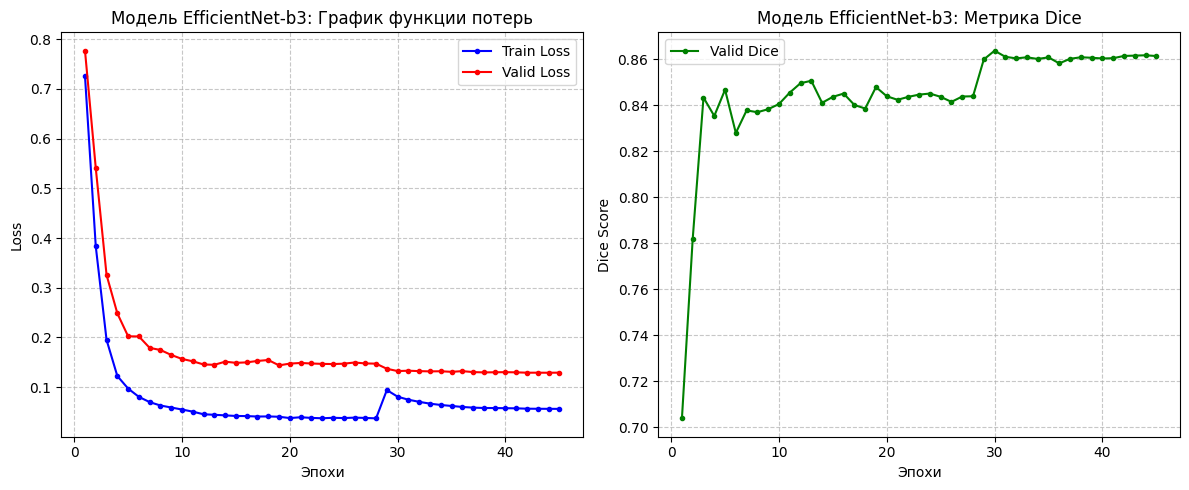

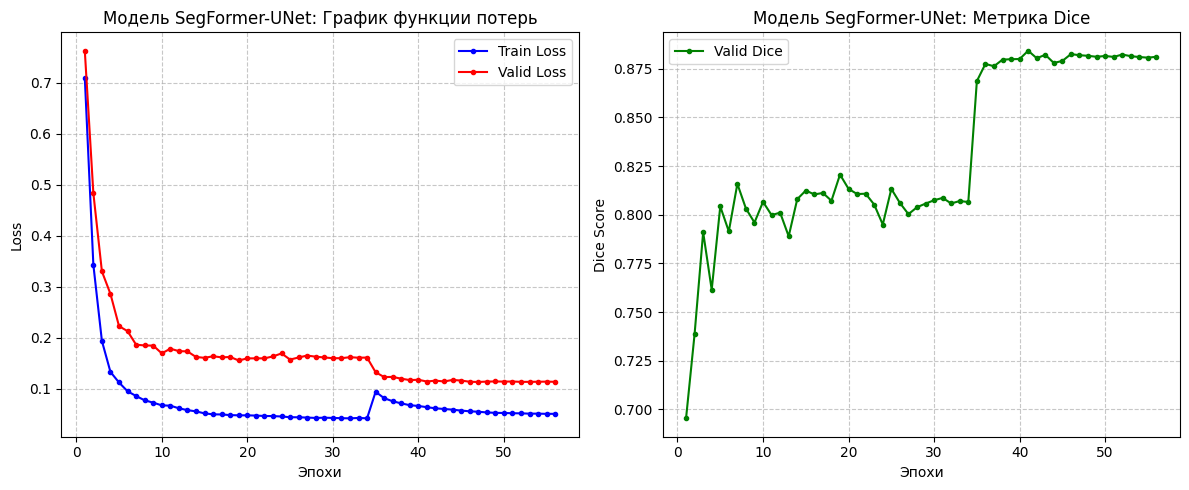

In [29]:
def plot_model_history(history, model_name):
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=3)
    plt.plot(epochs_range, history['val_loss'], label='Valid Loss', color='red', marker='o', markersize=3)
    plt.title(f'{model_name}: График функции потерь')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_dice'], label='Valid Dice', color='green', marker='o', markersize=3)
    plt.title(f'{model_name}: Метрика Dice')
    plt.xlabel('Эпохи')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


plot_model_history(history_unet, "Базовая модель UNet")

history_effnet_full = {
    'train_loss': history_effnet_stage1['train_loss'] + history_effnet_stage2['train_loss'],
    'val_loss': history_effnet_stage1['val_loss'] + history_effnet_stage2['val_loss'],
    'val_dice': history_effnet_stage1['val_dice'] + history_effnet_stage2['val_dice']
}
plot_model_history(history_effnet_full, "Модель EfficientNet-b3")

history_transf_full = {
    'train_loss': history_transf_stage1['train_loss'] + history_transf_stage2['train_loss'],
    'val_loss': history_transf_stage1['val_loss'] + history_transf_stage2['val_loss'],
    'val_dice': history_transf_stage1['val_dice'] + history_transf_stage2['val_dice']
}
plot_model_history(history_transf_full, "Модель SegFormer-UNet")

#### Поиск оптимального порога бинаризации

По умолчанию нейросеть предсказывает вероятности от 0 до 1, и маска строится по порогу 0.5. Иногда лучше сделать порог ниже, чтобы не пропустить края опухоли.

Сбор вероятностей для подбора порога: 100%|██████████| 11/11 [00:01<00:00,  8.49it/s]


Оптимальный порог: 0.20, mean patient Dice: 0.8855


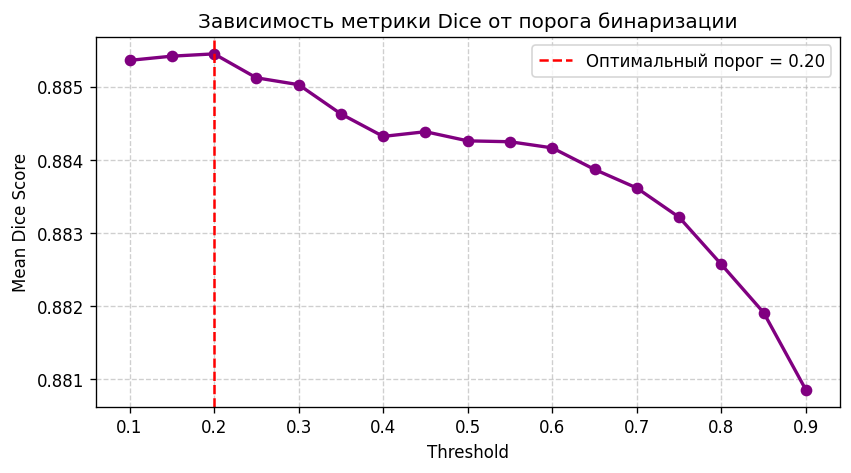

In [28]:
def find_best_threshold(model, loader_valid, device, thresholds=np.arange(0.1, 0.95, 0.05)):
    model.eval()
    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    validation_pred = []
    validation_true = []

    with torch.no_grad():
        for x, y_true in tqdm(loader_valid, desc="Сбор вероятностей для подбора порога"):
            x = x.to(device, non_blocking=True)
            x = imagenet_normalize(x)

            y_pred = model(x).float().cpu().numpy()
            y_true = y_true.float().cpu().numpy()

            validation_pred.extend(y_pred)
            validation_true.extend(y_true)

    best_threshold = 0.5
    best_dice = -1
    threshold_scores = []

    for t in thresholds:
        mean_dsc = np.mean(
            dsc_per_volume(
                validation_pred,
                validation_true,
                loader_valid.dataset.patient_slice_index,
                threshold=t
            )
        )
        threshold_scores.append((t, mean_dsc))

        if mean_dsc > best_dice:
            best_dice = mean_dsc
            best_threshold = t

    print(f"Оптимальный порог: {best_threshold:.2f}, mean patient Dice: {best_dice:.4f}")
    return best_threshold, threshold_scores

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
_, loader_valid = get_loaders(train_data, valid_data, batch_size=32)

best_unet = smp.Unet(
    encoder_name="mit_b2",
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=1, 
    activation='sigmoid'
)
best_unet.load_state_dict(torch.load(os.path.join(weights_path, "unet_transformer_finetuned_best.pt")))
best_unet.to(device)

best_threshold, threshold_scores = find_best_threshold(
    model=best_unet,
    loader_valid=loader_valid,
    device=device
)

thresholds, scores = zip(*threshold_scores)
plt.figure(figsize=(8, 4), dpi=120)
plt.plot(thresholds, scores, marker='o', color='purple', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.title("Зависимость метрики Dice от порога бинаризации")
plt.xlabel("Threshold")
plt.ylabel("Mean Dice Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Морфология

После бинаризации на маске может остаться мелкий шум - отдельные ложноположительные пиксели. Для очистки предсказаний можно применить алгоритмы компьютерного зрения:
1. Удалить все компоненты площадью меньше 10 пикселей, сохраняя при этом настоящие мультифокальные очаги опухоли.
2. Использовать морфологическую операцию закрытия `cv2.MORPH_CLOSE`, чтобы сгладить рваные края маски.
В конце замерить, как каждый этап подбор порога и морфология повлияли на итоговую метрику Dice.

In [15]:
def postprocess_mask(mask_prob, threshold=0.5):
    binary_mask = (mask_prob > threshold).astype(np.uint8)
    if np.sum(binary_mask) == 0:
        return binary_mask
        
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    
    if num_labels > 1:
        cleaned_mask = np.zeros_like(binary_mask)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= 10:
                cleaned_mask[labels == i] = 1
    else:
        cleaned_mask = binary_mask

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    final_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)
    return final_mask

def evaluate_all_steps_per_volume(model, loader_valid, device, best_thresh=0.5):
    model.eval()
    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    all_truth, all_prob, all_post = [], [], []
    
    with torch.no_grad():
        for x, y_true in tqdm(loader_valid, desc="Оценка пайплайна"):
            x = x.to(device, non_blocking=True)
            x = imagenet_normalize(x)
            
            y_pred_prob = model(x).cpu().numpy()
            y_true_np = y_true.cpu().numpy()
            
            for i in range(y_pred_prob.shape[0]):
                prob = y_pred_prob[i, 0]
                truth = y_true_np[i, 0]
                
                all_truth.append(truth)
                all_prob.append(prob)
                
                post_mask = postprocess_mask(prob, threshold=best_thresh)
                all_post.append(post_mask)
                
    patient_slice_index = loader_valid.dataset.patient_slice_index
    
    dice_baseline = np.mean(dsc_per_volume(all_prob, all_truth, patient_slice_index, threshold=0.5))
    dice_threshold = np.mean(dsc_per_volume(all_prob, all_truth, patient_slice_index, threshold=best_thresh))
    dice_morphology = np.mean(dsc_per_volume(all_post, all_truth, patient_slice_index, threshold=0.5))

    print("\nИТОГОВЫЕ РЕЗУЛЬТАТЫ")
    print(f"1. Бейзлайн (порог 0.5): {dice_baseline:.4f}")
    print(f"2. Оптимизация порога ({best_thresh:.2f}): {dice_threshold:.4f}")
    print(f"3. Оптимизированный порог + морфология: {dice_morphology:.4f}")

evaluate_all_steps_per_volume(model=best_unet, loader_valid=loader_valid, device=device, best_thresh=best_threshold)

Оценка пайплайна: 100%|██████████| 11/11 [00:01<00:00,  7.68it/s]



ИТОГОВЫЕ РЕЗУЛЬТАТЫ
1. Бейзлайн (порог 0.5): 0.8843
2. Оптимизация порога (0.20): 0.8855
3. Оптимизированный порог + морфология: 0.8879


#### Визуальный анализ предсказаний лучшей модели

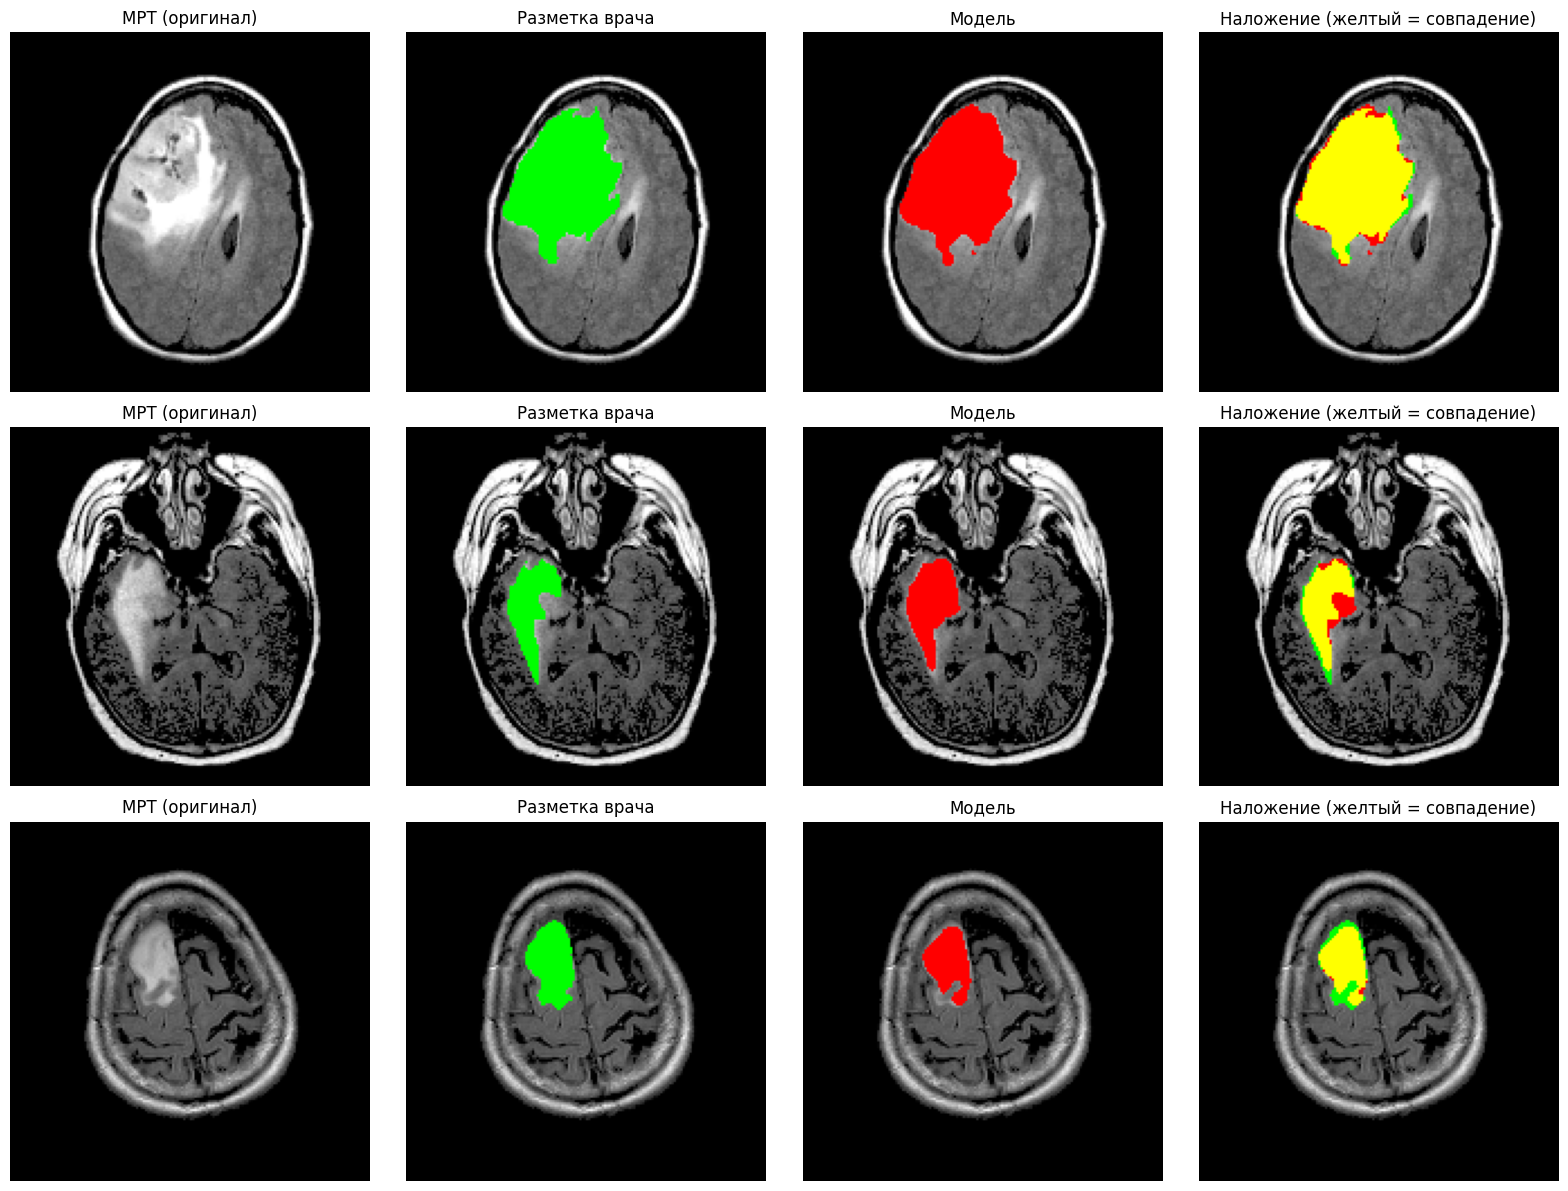

In [17]:
def visualize_predictions(model_path, dataset_dict, num_samples=3):
    viz_dataset = FastBrainDataset(dataset_dict, transform=None, random_sampling=False)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    model = smp.Unet(
        encoder_name="mit_b2",
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    valid_indices_with_tumor = []
    for i in range(len(viz_dataset)):
        _, mask = viz_dataset[i]
        if mask.sum() > 0:
            valid_indices_with_tumor.append(i)
            
    indices = np.random.choice(valid_indices_with_tumor, num_samples, replace=False)

    plt.figure(figsize=(16, 4 * num_samples))
    
    for i, idx in enumerate(indices):
        image_tensor, mask_tensor = viz_dataset[idx]
        
        with torch.no_grad():
            imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            x = imagenet_normalize(image_tensor).unsqueeze(0).to(device)
            pred = model(x)
            pred_mask = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)
        
        img = image_tensor[1].numpy()
        true_mask = mask_tensor.squeeze().numpy()

        img_rgb = np.stack((img,)*3, axis=-1)
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-5)

        plt.subplot(num_samples, 4, i * 4 + 1)
        plt.imshow(img, cmap='gray')
        plt.title("МРТ (оригинал)")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 2)
        overlay_true = img_rgb.copy()
        overlay_true[true_mask == 1] = [0, 1, 0]
        plt.imshow(overlay_true)
        plt.title("Разметка врача")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 3)
        overlay_pred = img_rgb.copy()
        overlay_pred[pred_mask == 1] = [1, 0, 0]
        plt.imshow(overlay_pred)
        plt.title("Модель")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 4)
        overlay_blend = img_rgb.copy()
        overlay_blend[true_mask == 1] = [0, 1, 0]
        
        overlay_blend[(pred_mask == 1) & (true_mask == 1)] = [1, 1, 0]
        overlay_blend[(pred_mask == 1) & (true_mask == 0)] = [1, 0, 0]
        overlay_blend[(pred_mask == 0) & (true_mask == 1)] = [0, 1, 0]

                        
        plt.imshow(overlay_blend)
        plt.title("Наложение (желтый = совпадение)")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_predictions("unet_transformer_finetuned_best.pt", valid_data, num_samples=3)


На примерах с валидационного набора видно, что гибридный трансформер SegFormer mit_b2 Encoder + UNet Decoder после fine-tuning`а хорошо восстанавливает форму и расположение опухоли.

**Желтые** области на итоговом наложении показывают пиксели, где предсказание точно совпадает с разметкой врача, **зеленые** — пропущенные участки опухоли, **красные** — ложноположительные пиксели модели.  
Для выбранных срезов преобладает желтый цвет, то есть модель находит основную массу опухоли, оставшиеся ошибки связаны с мелкими фрагментами и границами сегмента.


#### Разработка системы поиска похожих клинических случаев 

Cегментация опухоли — это первый этап. Врачу часто требуется изучить исторические аналогичные случаи (анамнез, тип опухоли, исход), чтобы назначить лечение.

Для этого трансформируем обученную модель.
Пропустим снимки пациентов через предобученный энкодер лучшей модели и извлечем векторные представления.

Так как пациент — это 3D-объем (набор 2D-срезов), итоговый вектор пациента получается путем взвешенного усреднения векторов его срезов, где вес — это площадь опухоли на срезе. Таким образом, эмбеддинг фокусируется именно на зоне поражения.

In [18]:
def extract_patient_embeddings_for_db(model, data_dict, device, best_thresh=0.45, split_name="unknown"):
    model.eval()

    imagenet_normalize = T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if isinstance(best_thresh, (tuple, list, np.ndarray)):
        best_thresh = float(best_thresh[0])
    else:
        best_thresh = float(best_thresh)

    patient_database = {}
    volumes = data_dict["volumes"]
    patients = data_dict["patients"]

    with torch.no_grad():
        for patient_idx, patient_id in enumerate(tqdm(patients, desc=f"Сбор эмбеддингов: {split_name}")):
            v, m = volumes[patient_idx]

            tensor_v = torch.from_numpy(
                v.transpose(0, 3, 1, 2).astype(np.float32)
            ).to(device)

            tensor_v = imagenet_normalize(tensor_v)

            pred_masks = model(tensor_v)
            binary_masks = (pred_masks > best_thresh).float()

            slice_weights = binary_masks.sum(dim=[1, 2, 3]).cpu().numpy().astype(np.float32)

            if slice_weights.sum() <= 1e-8:
                slice_weights = np.ones_like(slice_weights, dtype=np.float32)
            else:
                slice_weights = slice_weights + 1e-5

            features = model.encoder(tensor_v)
            bottleneck = features[-1]

            pooled_features = F.adaptive_avg_pool2d(bottleneck, (1, 1))
            slice_embeddings = pooled_features.view(tensor_v.size(0), -1).cpu().numpy()

            weights_normalized = slice_weights / slice_weights.sum()
            patient_emb = np.average(slice_embeddings, axis=0, weights=weights_normalized)

            norm = np.linalg.norm(patient_emb)
            if norm > 1e-12:
                patient_emb = patient_emb / norm

            patient_database[patient_id] = {
                "embedding": patient_emb.astype(np.float32).tolist(),
                "metadata": {
                    "patient_id": patient_id,
                    "split": split_name,
                    "total_slices": int(v.shape[0]),
                    "estimated_tumor_volume": float(slice_weights.sum()),
                    "best_threshold_used": float(best_thresh)
                }
            }

    print(f"Успешно сгенерированы векторы для {len(patient_database)} пациентов ({split_name}).")
    return patient_database

train_db = extract_patient_embeddings_for_db(
    model=best_unet,
    data_dict=train_data,
    device=device,
    best_thresh=best_threshold,
    split_name="train"
)

val_db = extract_patient_embeddings_for_db(
    model=best_unet,
    data_dict=valid_data,
    device=device,
    best_thresh=best_threshold,
    split_name="valid"
)

full_db = {}
full_db.update(train_db)
full_db.update(val_db)

print("\nГотово.")
print(f"Train patients: {len(train_db)}")
print(f"Valid patients: {len(val_db)}")
print(f"All patients: {len(full_db)}")

Сбор эмбеддингов: train: 100%|██████████| 100/100 [00:56<00:00,  1.76it/s]


Успешно сгенерированы векторы для 100 пациентов (train).


Сбор эмбеддингов: valid: 100%|██████████| 10/10 [00:02<00:00,  3.34it/s]

Успешно сгенерированы векторы для 10 пациентов (valid).

Готово.
Train patients: 100
Valid patients: 10
All patients: 110


#### Визуализация векторного пространства

Перед тем как строить поисковую базу, необходимо убедиться, что модель действительно выучила сложные семантические признаки, а не просто "запомнила" физический размер опухоли. 
Используем алгоритм **t-SNE** для снижения размерности эмбеддингов до 2D.

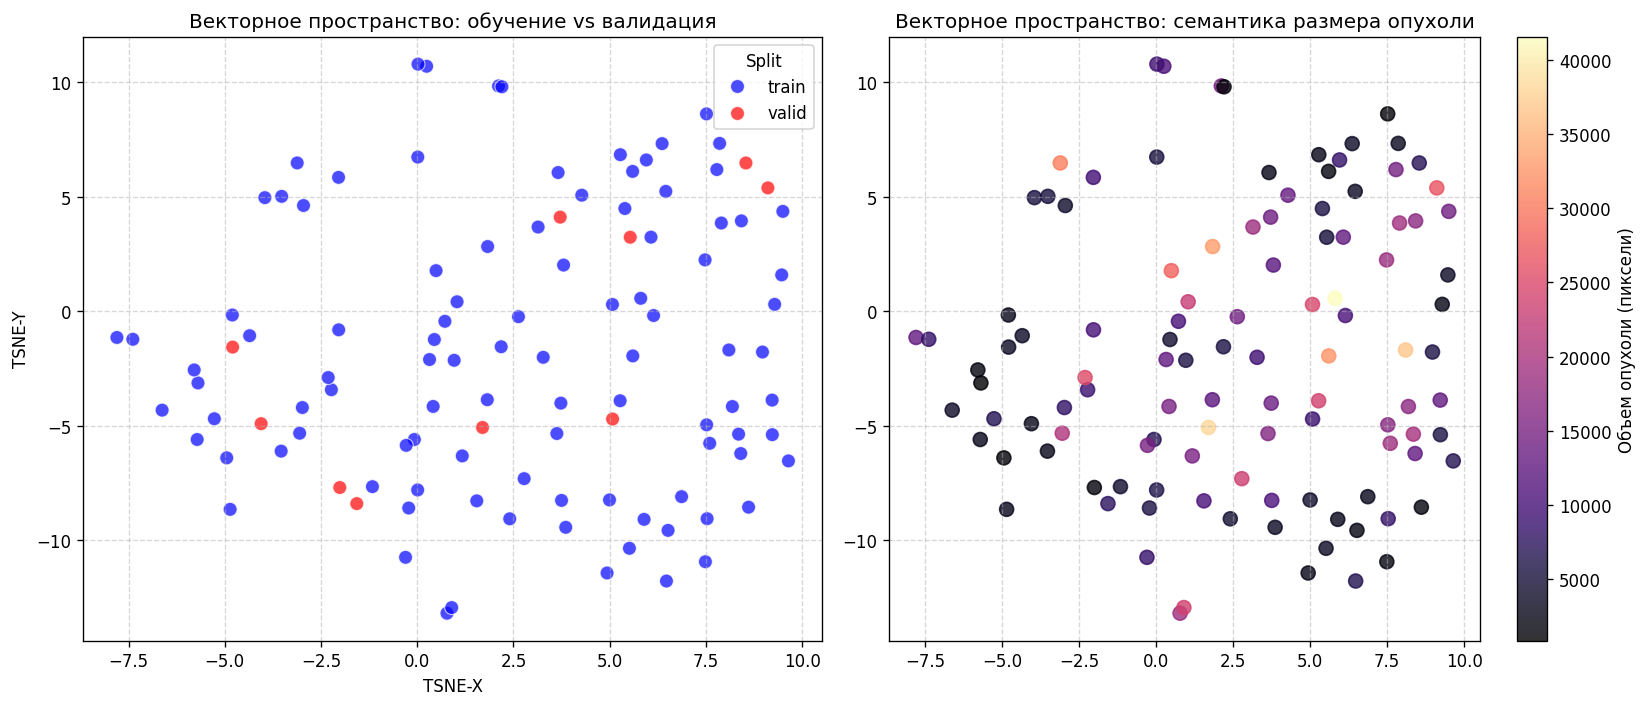

In [19]:
embeddings = []
volumes = []
splits = []
patient_ids = []

for p_id, data in full_db.items():
    embeddings.append(data["embedding"])
    volumes.append(data["metadata"]["estimated_tumor_volume"])
    splits.append(data["metadata"]["split"])
    patient_ids.append(p_id)

embeddings = np.array(embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=20)
embeddings_2d = tsne.fit_transform(embeddings)

df_tsne = pd.DataFrame({
    "TSNE-X": embeddings_2d[:, 0],
    "TSNE-Y": embeddings_2d[:, 1],
    "Volume": volumes,
    "Split": splits,
    "Patient": patient_ids
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

sns.scatterplot(
    data=df_tsne, x="TSNE-X", y="TSNE-Y", 
    hue="Split", palette={"train": "blue", "valid": "red"}, 
    alpha=0.7, s=70, ax=axes[0]
)
axes[0].set_title("Векторное пространство: обучение vs валидация")
axes[0].grid(True, linestyle='--', alpha=0.5)

scatter = axes[1].scatter(
    df_tsne["TSNE-X"], df_tsne["TSNE-Y"], 
    c=df_tsne["Volume"], cmap="magma", s=70, alpha=0.8
)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Объем опухоли (пиксели)")
axes[1].set_title("Векторное пространство: семантика размера опухоли")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Вывод:**
1. На левом графике точки из обучающей (синие) и валидационной (красные) выборок хорошо перемешаны. Это значит, что модель не переобучилась на тренировочных данных и умеет находить похожие паттерны в новых снимках.
2. Если бы модель видела только размер опухоли, точки на  графике 2 выстроились бы от темного к светлому, от маленьких опухолей к огромным. Но на графике видно, что точки разных цветов перемешаны. Получается, что нейросеть кодирует не просто площадь пятна, а сложную визуальную семантику (текстуру, изрезанность краев, анатомическое расположение). Именно поэтому поиск по векторам будет выдавать снимки, похожие по форме и типу, а не просто по размеру.


#### Интеграция с векторной базой данных Qdrant

Для организации быстрого поиска используется современная векторная БД **Qdrant**. 
Создается гибридная архитектура:
- **Вектор:** визуальный эмбеддинг опухоли от нейросети (отвечает за визуальное сходство).
- **Метаданные:** клинические данные пациента (возраст, пол, генетические кластеры, выживаемость).

In [20]:
csv_path = DATA_PATH / "data.csv"
clinical_df = pd.read_csv(csv_path)

client = QdrantClient(":memory:")
collection_name = "mri_tumor_cases"

first_patient_id = list(train_db.keys())[0]
vector_size = len(train_db[first_patient_id]["embedding"])

if client.collection_exists(collection_name):
    client.delete_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE),
)

def get_val(df, col_name, default="Неизвестно"):
    if col_name in df.columns and not pd.isna(df[col_name].values[0]):
        return df[col_name].values[0]
    return default

def get_best_slice(patient_id, dataset_dict):
    if patient_id in dataset_dict["patients"]:
        idx = dataset_dict["patients"].index(patient_id)
        vol, mask = dataset_dict["volumes"][idx]
    else:
        return None, None, None

    tumor_areas = mask.sum(axis=(1, 2, 3))
    best_slice_idx = np.argmax(tumor_areas)
    return vol[best_slice_idx], mask[best_slice_idx], best_slice_idx

points_to_upload = []

for idx, (patient_id, data) in enumerate(train_db.items()): 
    short_id = "_".join(patient_id.split("_")[:3]) 
    patient_info = clinical_df[(clinical_df['Patient'] == patient_id) | (clinical_df['Patient'] == short_id)]
    
    age = get_val(patient_info, 'age_at_initial_pathologic', -1)
    if age != -1: age = int(age)
    
    payload = data["metadata"].copy()
    payload.update({
        "age": age,
        "gender": str(get_val(patient_info, 'gender')),
        "histological_type": str(get_val(patient_info, 'histological_type')),
        "grade": str(get_val(patient_info, 'neoplasm_histologic_grade')),
        "location": str(get_val(patient_info, 'tumor_location')),
        "death01": get_val(patient_info, 'death01', -1),
        "rna_cluster": str(get_val(patient_info, 'RNASeqCluster')),
        "meth_cluster": str(get_val(patient_info, 'MethylationCluster'))
    })
    
    points_to_upload.append(PointStruct(id=idx, vector=data["embedding"], payload=payload))

client.upsert(collection_name=collection_name, wait=True, points=points_to_upload)
print(f"В историческую базу загружено {len(points_to_upload)} пациентов (Train).")

В историческую базу загружено 100 пациентов (Train).



Новый пациент: TCGA_DU_7014_19860618
Вводные данные от врача: Возраст 59 лет, Пол: 2.0
Результат работы модели: Оценочный объем опухоли 26605.0 пикс.



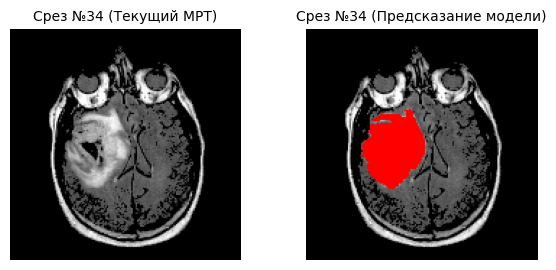


НАЙДЕННЫЕ ИСТОРИЧЕСКИЕ СОВПАДЕНИЯ В БАЗЕ:
---------------------------------------------------------------------------
[1] ПОХОЖИЙ ИСТОРИЧЕСКИЙ СЛУЧАЙ (ID: TCGA_DU_6400_19830518) | Визуальное сходство: 0.8621
 Пациент: Возраст 66 лет, Пол: 1.0
 Опухоль: Тип '3.0', Степень (Grade): 1.0
 Локация: 6.0 | Объем маски: 14653.0 пикселей
 Генетика: RNA Кластер: 3.0, Метилирование: 2.0
 Исход: УМЕР (1)


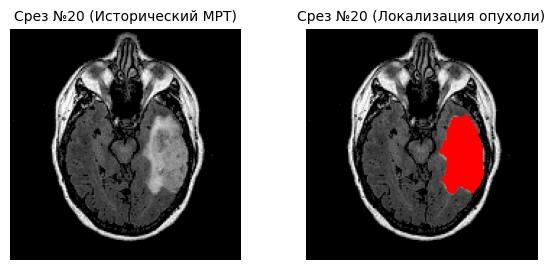

---------------------------------------------------------------------------
[2] ПОХОЖИЙ ИСТОРИЧЕСКИЙ СЛУЧАЙ (ID: TCGA_DU_A5TS_19970726) | Визуальное сходство: 0.8612
 Пациент: Возраст 42 лет, Пол: 2.0
 Опухоль: Тип '3.0', Степень (Grade): 1.0
 Локация: 2.0 | Объем маски: 14261.0 пикселей
 Генетика: RNA Кластер: Неизвестно, Метилирование: 5.0
 Исход: ВЫЖИЛ (0)


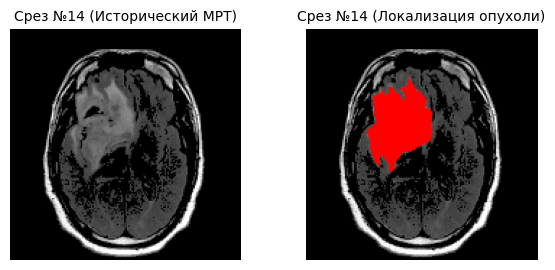

---------------------------------------------------------------------------
[3] ПОХОЖИЙ ИСТОРИЧЕСКИЙ СЛУЧАЙ (ID: TCGA_DU_7008_19830723) | Визуальное сходство: 0.8591
 Пациент: Возраст 41 лет, Пол: 1.0
 Опухоль: Тип '3.0', Степень (Grade): 1.0
 Локация: 2.0 | Объем маски: 41559.0 пикселей
 Генетика: RNA Кластер: 4.0, Метилирование: 3.0
 Исход: ВЫЖИЛ (0)


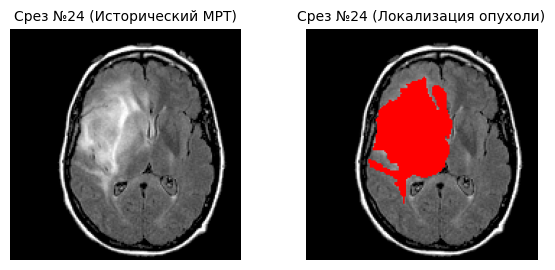

---------------------------------------------------------------------------


In [25]:
query_patient_id = random.choice(list(val_db.keys()))
query_short_id = "_".join(query_patient_id.split("_")[:3])
query_vector = val_db[query_patient_id]["embedding"]
query_volume = val_db[query_patient_id]["metadata"]["estimated_tumor_volume"]

query_info = clinical_df[(clinical_df['Patient'] == query_patient_id) | (clinical_df['Patient'] == query_short_id)]
target_age = get_val(query_info, 'age_at_initial_pathologic', -1)
if target_age != -1: target_age = int(target_age)
target_gender = str(get_val(query_info, 'gender'))

print(f"\n==========================================================")
print(f"Новый пациент: {query_patient_id}")
print(f"Вводные данные от врача: Возраст {target_age if target_age != -1 else 'Неизвестно'} лет, Пол: {target_gender}")
print(f"Результат работы модели: Оценочный объем опухоли {query_volume:.1f} пикс.")
print(f"==========================================================\n")

best_img_q, best_mask_q, slice_idx_q = get_best_slice(query_patient_id, valid_data)
if best_img_q is not None:
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    
    axes[0].imshow(best_img_q[:, :, 1], cmap='gray')
    axes[0].set_title(f"Срез №{slice_idx_q} (Текущий МРТ)", fontsize=10)
    axes[0].axis('off')
    
    img_q = best_img_q[:, :, 1]
    img_rgb_q = np.stack((img_q,) * 3, axis=-1)
    mask_2d_q = best_mask_q[:, :, 0]
    
    overlay_q = img_rgb_q.copy()
    overlay_q[mask_2d_q == 1] = [1, 0, 0]
    
    axes[1].imshow(overlay_q)
    axes[1].set_title(f"Срез №{slice_idx_q} (Предсказание модели)", fontsize=10)
    axes[1].axis('off')
    
    plt.show() 

print("\nНАЙДЕННЫЕ ИСТОРИЧЕСКИЕ СОВПАДЕНИЯ В БАЗЕ:")
print("-" * 75)
    
query_filter = Filter(
    must_not=[
        FieldCondition(
            key="patient_id",
            match=MatchValue(value=query_patient_id)
        )
    ]
)

response = client.query_points(
    collection_name=collection_name,
    query=query_vector,
    query_filter=query_filter, 
    limit=3
)

for i, hit in enumerate(response.points):
    payload = hit.payload
    p_id = payload['patient_id']
    
    print(f"[{i+1}] ПОХОЖИЙ ИСТОРИЧЕСКИЙ СЛУЧАЙ (ID: {p_id}) | Визуальное сходство: {hit.score:.4f}")
    print(f" Пациент: Возраст {payload.get('age', 'Неизвестно')} лет, Пол: {payload.get('gender')}")
    print(f" Опухоль: Тип '{payload.get('histological_type')}', Степень (Grade): {payload.get('grade')}")
    print(f" Локация: {payload.get('location')} | Объем маски: {payload.get('estimated_tumor_volume', 0):.1f} пикселей")
    print(f" Генетика: RNA Кластер: {payload.get('rna_cluster')}, Метилирование: {payload.get('meth_cluster')}")
    
    death_status = payload.get('death01', -1)
    death_str = "УМЕР (1)" if death_status == 1 else "ВЫЖИЛ (0)" if death_status == 0 else "Нет данных"
    print(f" Исход: {death_str}")
    
    best_img, best_mask, slice_idx = get_best_slice(p_id, train_data)
    
    if best_img is not None:
        fig, axes = plt.subplots(1, 2, figsize=(7, 3))
        
        axes[0].imshow(best_img[:, :, 1], cmap='gray')
        axes[0].set_title(f"Срез №{slice_idx} (Исторический МРТ)", fontsize=10)
        axes[0].axis('off')
        
        img = best_img[:, :, 1]
        img_rgb = np.stack((img,) * 3, axis=-1)
        mask_2d = best_mask[:, :, 0]
        
        overlay = img_rgb.copy()
        overlay[mask_2d == 1] = [1, 0, 0]
        
        axes[1].imshow(overlay)

        axes[1].set_title(f"Срез №{slice_idx} (Локализация опухоли)", fontsize=10)
        axes[1].axis('off')
        
        plt.show() 
        
    print("-" * 75)

#### Оценка качества системы поиска

Для каждого валидационного пациента система находит 3 самых визуально похожих исторических случая, после чего проверяется, насколько совпали их клинические диагнозы.

**Описание метрик:**
- Точность по гистологии - показывает, в какой доле найденных случаев гистологический тип рака совпал с диагнозом исходного пациента.
- Точность по степени - показывает, в какой доле найденных исторических снимков степень злокачественности опухоли совпала со степенью злокачественности исходного пациента.
- Ошибка объема - насколько в процентах найденные опухоли отличаются от искомой по размеру в пикселях.

In [26]:
def system_quality(client, collection_name, val_db, clinical_df, k=3):
    histology_precision = []
    grade_precision = []
    volume_errors = []
    
    def get_val_df(df, col_name, default="Неизвестно"):
        if col_name in df.columns and len(df) > 0 and not pd.isna(df[col_name].values[0]):
            return df[col_name].values[0]
        return default
    
    for q_patient_id, q_data in val_db.items():
        q_vector = q_data["embedding"]
        q_volume = q_data["metadata"]["estimated_tumor_volume"]
        
        q_short_id = "_".join(q_patient_id.split("_")[:3])
        q_info = clinical_df[(clinical_df['Patient'] == q_patient_id) | (clinical_df['Patient'] == q_short_id)]
        
        q_histology = str(get_val_df(q_info, 'histological_type'))
        q_grade = str(get_val_df(q_info, 'neoplasm_histologic_grade'))
        q_age = get_val_df(q_info, 'age_at_initial_pathologic', -1)
        
        must_conditions = []
            
        query_filter = Filter(
            must_not=[
                FieldCondition(
                    key="patient_id",
                    match=MatchValue(value=q_patient_id)
                )
            ]
        )
        
        try:
            response = client.query_points(
                collection_name=collection_name,
                query=q_vector,
                query_filter=query_filter, 
                limit=k
            )
        except Exception as e:
            print(f"Ошибка при запросе к Qdrant для пациента {q_patient_id}: {e}")
            continue
            
        hit_histology_matches = 0
        hit_grade_matches = 0
        patient_vol_errors = []
        
        valid_hist_hits = 0
        valid_grade_hits = 0
        
        for hit in response.points:
            payload = hit.payload
            hit_histology = payload.get('histological_type', 'Неизвестно')
            hit_grade = payload.get('grade', 'Неизвестно')
            hit_volume = payload.get('estimated_tumor_volume', 0.0)
            
            if q_histology != "Неизвестно" and hit_histology != "Неизвестно":
                valid_hist_hits += 1
                if q_histology == hit_histology:
                    hit_histology_matches += 1
                    
            if q_grade != "Неизвестно" and hit_grade != "Неизвестно":
                valid_grade_hits += 1
                if q_grade == hit_grade:
                    hit_grade_matches += 1
            
            denom = max(q_volume, 1.0)
            vol_err = abs(q_volume - hit_volume) / denom
            patient_vol_errors.append(vol_err)
            
        if valid_hist_hits > 0:
            histology_precision.append(hit_histology_matches / valid_hist_hits)
        if valid_grade_hits > 0:
            grade_precision.append(hit_grade_matches / valid_grade_hits)
        if patient_vol_errors:
            volume_errors.append(np.mean(patient_vol_errors))
            
    print("Отчет о качестве работы поисковой системы")
    if histology_precision:
        print(f"1. Точность по гистологическому типу (Precision@{k}): {np.mean(histology_precision):.4f}")
    else:
        print("1. Точность по гистологии: недостаточно данных в датасете")
        
    if grade_precision:
        print(f"2. Точность по степени злокачественности (Precision@{k}): {np.mean(grade_precision):.4f}")
    else:
        print("2. Точность по грейду: недостаточно данных в датасете")
        
    if volume_errors:
        mean_vol_err = np.mean(volume_errors) * 100
        print(f"3. Средняя ошибка объема опухоли у найденных случаев: {mean_vol_err:.2f}%")
    else:
        print("3. Ошибка объема: недостаточно данных в датасете")

system_quality(client, collection_name, val_db, clinical_df, k=3)

Отчет о качестве работы поисковой системы
1. Точность по гистологическому типу (Precision@3): 0.4667
2. Точность по степени злокачественности (Precision@3): 0.5000
3. Средняя ошибка объема опухоли у найденных случаев: 124.85%
